***NeuroVision:***
A neuroimaging AI system that analyzes brain scans- fMRI to learn the relationship between brain activity and specific motor tasks. A deep-learning model will classify the task being performed (e.g., left-hand, right-hand, foot or tongue movement), identify the brain regions contributing to the prediction using explainable AI, and visualize the predicted brain activity and corresponding movement on a 3D digital human twin.

In [1]:
#importing dependancies
import numpy as np, pandas as pd, matplotlib.pyplot as plt, scipy as spy, random as rd
import glob 
import nibabel as nib
import torch 
import re 

In [3]:

f = nib.load("data/raw/ds004044/derivatives/ciftify/sub-02/results/ses-1_task-motor_hp200_s4_level2.feat/sub-02_ses-1_task-motor_level2_cope_Ankle_hp200_s4.dscalar.nii")
data = f.get_fdata()
#this is how the data in the file looks like
print(f"shape:{data.shape}")
print(f"original:{data}")

#what we want:
print(f"what we want: {data[0]}")


shape:(1, 91282)
original:[[-0.64477587  3.17282152  1.60026658 ... -0.29940793  0.72624058
   1.37348568]]
what we want: [-0.64477587  3.17282152  1.60026658 ... -0.29940793  0.72624058
  1.37348568]


Extracting the single string data

In [2]:
CONDS = ['Forearm', 'Lip', 'LeftLeg', 'Tongue', 'Upperarm', 'RightLeg', 'Wrist', 'Jaw', 'Eye', 'Toe', 'Finger', 'Ankle']

In [ ]:
#SAMPLE
#reading files from ds004044 and storing them

CONDS = ['Forearm', 'Lip', 'LeftLeg', 'Tongue', 'Upperarm', 'RightLeg', 'Wrist', 'Jaw', 'Eye', 'Toe', 'Finger', 'Ankle']

dataset = {}


for f in glob.glob("data/raw/ds004044/derivatives/ciftify/sub-*/results/ses-1_task-motor_hp200_s4_level2.feat/sub-*_ses-1_task-motor_level2_cope_*_hp200_s4.dscalar.nii"):
    match = re.search(r"cope_(.+?)_hp200", f)

    if match:
        cond = match.group(1)
        values = nib.load(f).get_fdata()[0]

        dataset.setdefault(cond, []).append(values)


    




In [5]:
print(dataset.keys())

for cond in dataset:
    print(cond, len(dataset[cond]))

dict_keys(['Forearm', 'Lip', 'LeftLeg', 'Tongue', 'Upperarm', 'RightLeg', 'Wrist', 'Jaw', 'Eye', 'Toe', 'Finger', 'Ankle'])
Forearm 62
Lip 62
LeftLeg 62
Tongue 62
Upperarm 62
RightLeg 62
Wrist 62
Jaw 62
Eye 62
Toe 62
Finger 62
Ankle 62


In [15]:
a = dataset["Ankle"][61]

print(a)


[-0.21329264  2.43942761 12.98373508 ...  1.51338029  0.50122684
 -0.11629667]


group by subjects, why?
The scientifically meaningful claim is: can it decode movement on a subject it has never seen?
so we split groups apart

In [ ]:
#spllit the data from the dataset into training vs testing

test_subj_idx=np.random.choice(62, size=10, replace=False)
print(test_subj_idx)

#[54 16 47 21 45 31  8 40 24 37] -if sm happens these are the test subjects




[54 16 47 21 45 31  8 40 24 37]


In [57]:
d_test=[]
d_train=[]



In [58]:
for idx in test_subj_idx:
    for part in dataset.keys():
        ting = (idx, part,dataset[part][idx])

        d_test.append(ting)
        

for i in range(62):
    if i not in test_subj_idx:
        for part in dataset.keys():
            bing = (i, part,dataset[part][i])
            d_train.append(bing)



    

print(f"train: {len(d_train)} and test: {len(d_test)}")
    

        

    

train: 624 and test: 120


Now we have separated the train vs test, lets now downlaod it, then, make x-train/test and y-train/test

In [59]:
print(d_test[:5])
print(d_train[:5])

[(np.int64(54), 'Forearm', array([ 0.41837218,  8.18006706, -4.95341539, ...,  0.11794937,
        0.38200337, -0.06382387])), (np.int64(54), 'Lip', array([ 0.03442095, -2.82097316, 19.37366486, ..., -0.25850093,
       -0.42002693, -0.69459248])), (np.int64(54), 'LeftLeg', array([-0.86472601,  3.63964939, -1.70567513, ..., -2.5367341 ,
       -3.41674089,  2.3351686 ])), (np.int64(54), 'Tongue', array([-0.76091665, -2.86396122, 19.50681114, ..., -0.85534251,
       -0.67557478, -0.47586805])), (np.int64(54), 'Upperarm', array([-0.37045652,  7.29386997, -9.50294971, ...,  1.46052372,
        1.40040231, -0.67837697]))]
[(0, 'Forearm', array([-2.00238395, -0.37611616,  2.22823524, ...,  1.69209909,
        2.65287161,  2.86193728])), (0, 'Lip', array([-0.39549112,  3.2869215 , 22.18546104, ...,  1.93187726,
        1.49418223,  2.52106929])), (0, 'LeftLeg', array([-3.99210382, 11.43785286, -2.4330554 , ..., -1.33465636,
       -1.24167669, -2.08966184])), (0, 'Tongue', array([-1.6490224

In [66]:
import pickle, os
os.makedirs("data/processed", exist_ok=True)

# optional: shrink to float32 first to halve disk (~455MB -> ~227MB)
d_train = [(s, c, v.astype(np.float32)) for (s, c, v) in d_train]
d_test  = [(s, c, v.astype(np.float32)) for (s, c, v) in d_test]

with open("data/processed/d_train.pkl", "wb") as f:
    pickle.dump(d_train, f)
with open("data/processed/d_test.pkl", "wb") as f:
    pickle.dump(d_test, f)

In [3]:
#load them back w this:
import pickle

with open("data/processed/d_train.pkl", "rb") as f:
    d_train = pickle.load(f)
with open("data/processed/d_test.pkl", "rb") as f:
    d_test = pickle.load(f)

Labels for conditions.
CONDS --> 'Forearm' : 0 , 'Lip': 1 , 'LeftLeg': 2 , 'Tongue': 3 , 'Upperarm': 4 , 'RightLeg': 5 , 'Wrist': 6 , 'Jaw': 7 , 'Eye': 8 , 'Toe': 9 , 'Finger': 10, 'Ankle': 11


In [4]:
x_tr = np.stack([t[2] for t in d_train]).astype(np.float32) #624, 91282 
y_tr = np.array([CONDS.index(t[1]) for t in d_train]) #624, -indexs of the conditioins from CONDS[]
g_tr = np.array([t[0] for t in d_train]) #624, -subjects

x_te = np.stack([n[2] for n in d_test]).astype(np.float32)#120,91282
y_te = np.array([CONDS.index(n[1]) for n in d_test])
g_te = np.array([n[0] for n in d_test])

print(x_tr)
print()
print(x_te)

x_tr[0][:59412]

[[-2.002384   -0.37611616  2.2282352  ...  1.6920991   2.6528716
   2.8619373 ]
 [-0.39549112  3.2869215  22.185461   ...  1.9318773   1.4941822
   2.5210693 ]
 [-3.9921038  11.437853   -2.4330554  ... -1.3346564  -1.2416767
  -2.0896618 ]
 ...
 [ 2.6819725   5.292506   17.138597   ...  1.819661   -0.031351
  -0.7108047 ]
 [ 0.22194985 -8.920849   17.718147   ...  1.0098006   0.14610319
   2.3995588 ]
 [-0.21329264  2.4394276  12.983735   ...  1.5133803   0.50122684
  -0.11629667]]

[[ 0.41837218  8.180067   -4.9534154  ...  0.11794937  0.38200337
  -0.06382387]
 [ 0.03442095 -2.8209732  19.373665   ... -0.25850093 -0.42002693
  -0.6945925 ]
 [-0.864726    3.6396494  -1.7056751  ... -2.536734   -3.416741
   2.3351686 ]
 ...
 [ 0.3990943   1.7324927   7.427002   ...  0.92875564  1.6844473
   3.079024  ]
 [-1.4999598   5.1166925   4.200473   ...  1.7141048   1.9906503
   2.5214124 ]
 [ 0.5619197   8.958911   -1.6099988  ... -1.1327997  -1.0899205
  -1.630381  ]]


array([-2.002384  , -0.37611616,  2.2282352 , ...,  0.67093337,
       -1.3222772 , -1.5775218 ], dtype=float32)

Importing a basic linear model to work with first.

In [5]:
#import all the dependencies
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=0.1, max_iter=3000))
])

clf.fit(x_tr, y_tr)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(C=0.1, max_iter=3000))])

In [7]:
prediction = clf.predict(x_te)
print("accuracy",accuracy_score(y_te, prediction))
print(classification_report(y_te, prediction, target_names=CONDS, digits=3))
print("conf matx:", confusion_matrix(y_te, prediction))

coef = clf.named_steps["lr"].coef_     # shape (12, 91282) -> your first brain map
print("coef shape:", coef.shape)

accuracy 0.85
              precision    recall  f1-score   support

     Forearm      0.700     0.700     0.700        10
         Lip      1.000     0.900     0.947        10
     LeftLeg      1.000     0.800     0.889        10
      Tongue      0.889     0.800     0.842        10
    Upperarm      0.778     0.700     0.737        10
    RightLeg      0.900     0.900     0.900        10
       Wrist      0.643     0.900     0.750        10
         Jaw      0.727     0.800     0.762        10
         Eye      0.909     1.000     0.952        10
         Toe      0.833     1.000     0.909        10
      Finger      1.000     0.900     0.947        10
       Ankle      1.000     0.800     0.889        10

    accuracy                          0.850       120
   macro avg      0.865     0.850     0.852       120
weighted avg      0.865     0.850     0.852       120

conf matx: [[ 7  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  9  0  0  0  0  0  1  0  0  0  0]
 [ 0  0  8  0  1  1  0  0  0  

In [25]:
pred = clf.predict(x_te)
ok = (pred == y_te)
print("correct:", ok.sum(), "/", len(y_te))
wrong = np.where(~ok)[0]
c=0
for i in wrong[:]:
    c+=1

    print(f"case {i}: true={CONDS[y_te[i]]}, pred={CONDS[pred[i]]}")
print("total, wronged:", c)

correct: 102 / 120
case 12: true=Forearm, pred=Wrist
case 16: true=Upperarm, pred=Wrist
case 31: true=Jaw, pred=Tongue
case 39: true=Tongue, pred=Jaw
case 46: true=Finger, pred=Wrist
case 48: true=Forearm, pred=Wrist
case 50: true=LeftLeg, pred=Upperarm
case 53: true=RightLeg, pred=Upperarm
case 63: true=Tongue, pred=Jaw
case 66: true=Wrist, pred=Forearm
case 71: true=Ankle, pred=Toe
case 79: true=Jaw, pred=Eye
case 84: true=Forearm, pred=Wrist
case 85: true=Lip, pred=Jaw
case 88: true=Upperarm, pred=Forearm
case 98: true=LeftLeg, pred=RightLeg
case 107: true=Ankle, pred=Toe
case 112: true=Upperarm, pred=Forearm
total, wronged: 18


In [9]:
#pred machine

idx = np.random.choice(120,size = 1, replace =False)
print(f"Case:{idx}")
pred = clf.predict(x_te[idx])

print(f"Subject is moving their: {CONDS[pred[0]]}")
print(f"Correct? {(pred == y_te[idx])}")


Case:[57]
Subject is moving their: Toe
Correct? [ True]


**----------------------------------------**

**Lets. use. a. GCN**

In [ ]:
import nibabel as nib
img = nib.load("data/raw/ds004044/derivatives/ciftify/sub-02/results/ses-1_task-motor_hp200_s4_level2.feat/sub-02_ses-1_task-motor_level2_cope_Toe_hp200_s4.dscalar.nii")
ax = img.header.get_axis(1)     # same BrainModelAxis object as before
for s in ax.iter_structures():  # loop over one entry per brain structure
    print(s)                    # show what that entry contains

('CIFTI_STRUCTURE_CORTEX_LEFT', slice(0, 29696, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9ac0>)
('CIFTI_STRUCTURE_CORTEX_RIGHT', slice(29696, 59412, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9e20>)
('CIFTI_STRUCTURE_ACCUMBENS_LEFT', slice(59412, 59547, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9ac0>)
('CIFTI_STRUCTURE_ACCUMBENS_RIGHT', slice(59547, 59687, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9e20>)
('CIFTI_STRUCTURE_AMYGDALA_LEFT', slice(59687, 60002, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9ac0>)
('CIFTI_STRUCTURE_AMYGDALA_RIGHT', slice(60002, 60334, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9e20>)
('CIFTI_STRUCTURE_BRAIN_STEM', slice(60334, 63806, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object at 0x1306e9ac0>)
('CIFTI_STRUCTURE_CAUDATE_LEFT', slice(63806, 64534, None), <nibabel.cifti2.cifti2_axes.BrainModelAxis object 

In [ ]:
#demo case...

vec =img.get_fdata()[0]

#Cortex greyordinates
C = vec[0:59412]

#Input Node Actvation Matrix
H = C.reshape(-1,1)
print(cH)

#graph container
data = Data(x=torch.tensor(H), edge_index= edge_index, y=torch.tensor(9))

#Edge_Index is our connection matrix(Â).. we'll write a bunch of code to get that later hehe...

[[-1.2089262 ]
 [ 7.4245863 ]
 [ 6.13234329]
 ...
 [ 0.11400351]
 [ 0.21366464]
 [ 0.21217445]]


NameError: name 'edge_index' is not defined

In [79]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_max_pool
from torch import nn


In [43]:
#Separating the Cortical nodes vs the Subcortical ones
#Going to use H, in GCN
C = np.stack([v[0:59412] for v in x_tr]).astype(np.float32) #Array of Cortical node vector containing 1 feature /node.
H = np.stack([u.reshape(-1,1) for u in C]) #Array of multiple Input node activation matrices

#we need S for MLP not for GCN
S = np.stack([v[59412:] for v in x_tr]).astype(np.float32) #Array of Subcortical node vector conntaining 1 feature /node.

print(H.shape)
S.shape


(624, 59412, 1)


(624, 31870)

In [80]:
#Making the GCN for Cortical nodes:

class BrainGCN(torch.nn.Module):
    def __init__(self, in_ch=1, hid=32, n_class=12):
        
        '''
        in_ch=1 → input channels = features per node, We have 1 feature per node.  
        hid=32 → hidden width = descriptors per node after layer 1... will help later with summary vector (Vs)
        n_class=12 → output classes =  12 movements (CONDS).
         
        '''

        #This triggers PyTorch's internal setup (registers parameters, GPU support, etc.)
        super().__init__()

        self.conv1= GCNConv(in_ch, hid)   #1st Graph Conv Operation
        self.conv2= GCNConv(hid,hid)
        self.lin = nn.Linear(hid, n_class)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_max_pool(x, batch)
        return self.lin(x)

    

    


In [46]:
surfs = fetch_fslr()
print(type(surfs))
print(list(surfs.keys()))
print(surfs['midthickness'])

<class 'sklearn.utils._bunch.Bunch'>
['midthickness', 'inflated', 'veryinflated', 'sphere', 'medial', 'sulc', 'vaavg']
Surface(L=PosixPath('/Users/samirahsan/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'), R=PosixPath('/Users/samirahsan/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-R_midthickness.surf.gii'))


In [131]:
#Creating edge index (A):

from neuromaps.datasets import fetch_fslr #importing the ready-made brain mesh template 
import nibabel as nib, numpy as np, torch

surfs = fetch_fslr()
L= nib.load(surfs['midthickness'].L)
R= nib.load(surfs['midthickness'].R)

#face tables. Concept: these define neighbour nodes
Lf = L.agg_data('triangle')
Rf = R.agg_data('triangle')

#left vertex count (32,492). Concept: both hemispheres number from 0, so this offset merges them into one address space (right vertex 0 becomes nL).
nL = L.agg_data('pointset').shape[0]

#making the connections meathod:

def edges_from_faces(faces):
    e = np.vstack([faces[:, :2], faces[:, 1:], faces[:, [0, 2]]])
    return np.unique(np.sort(e, axis=1), axis=0)


#meathod in action

el = edges_from_faces(Lf)
er = edges_from_faces(Rf) + nL
E = np.vstack([el, er])
A = torch.tensor(np.concatenate([E.T, E[:, ::-1].T], axis=1), dtype=torch.long)
print(A.shape)

torch.Size([2, 389880])


In [132]:
ax = img.header.get_axis(1)
for name, slc, bm in ax.iter_structures():
    if name == 'CIFTI_STRUCTURE_CORTEX_LEFT':
        vL = np.asarray(bm.vertex)
    if name == 'CIFTI_STRUCTURE_CORTEX_RIGHT':
        vR = np.asarray(bm.vertex)
print(len(vL), len(vR))

29696 29716


In [133]:
#placing the entries in the mesh

ax = img.header.get_axis(1)
for name, slc, bm in ax.iter_structures():
    if name == 'CIFTI_STRUCTURE_CORTEX_LEFT':
        vL = np.asarray(bm.vertex) #29696
    if name == 'CIFTI_STRUCTURE_CORTEX_RIGHT':
        vR = np.asarray(bm.vertex) #29716

nR = R.agg_data('pointset').shape[0]
Xfull_tr = np.zeros((624, nL + nR), dtype=np.float32)
Xfull_tr[:, vL] = C[:, 0:29696]
Xfull_tr[:, vR + nL] = C[:, 29696:59412]
print(Xfull_tr[:5, 59412:])

'''
In Xfull_tr (mesh order, 64,984 wide),
The medial wall indices are mixed in between the cortical nodes.

0 - 32,491 → LEFT mesh vertices (nL = 32,492 of them), in mesh order.
vL (29,696 of these indices) → cortical, carry values.
The remaining ~2,796 (mesh indices not in vL) → left medial wall, zeros.
32,492 - 64,983 → RIGHT mesh vertices, in mesh order.
vR + nL (29,716 of these) → cortical, carry values.
The remaining ~2,776 → right medial wall, zeros.
'''

[[  0.           0.           0.         ...   0.67093337  -1.3222772
   -1.5775218 ]
 [  0.           0.           0.         ...  -0.12164428  -2.0250952
   -2.5262103 ]
 [  0.           0.           0.         ...  -1.6375046  -16.121126
  -14.879394  ]
 [  0.           0.           0.         ...  -5.4938455   -4.555698
   -5.183108  ]
 [  0.           0.           0.         ...  -7.9816666   -5.140187
   -5.7255993 ]]


'\nIn Xfull_tr (mesh order, 64,984 wide),\nThe medial wall indices are mixed in between the cortical nodes.\n\n0 - 32,491 → LEFT mesh vertices (nL = 32,492 of them), in mesh order.\nvL (29,696 of these indices) → cortical, carry values.\nThe remaining ~2,796 (mesh indices not in vL) → left medial wall, zeros.\n32,492 - 64,983 → RIGHT mesh vertices, in mesh order.\nvR + nL (29,716 of these) → cortical, carry values.\nThe remaining ~2,776 → right medial wall, zeros.\n'

In [134]:
#Attaching graph box per and then batching them

'''
Data - graph box, 1 graph ber box
DataLoader - batching machine, batches graphs into multiple batches for training
'''

train_list = []

#attaching
for i in range(624):
    x = torch.tensor(Xfull_tr[i].reshape(-1, 1))
    y = torch.tensor(int(y_tr[i]), dtype=torch.long)
    train_list.append(Data(x=x, edge_index=A, y=y))

#batching
loader = DataLoader(train_list, batch_size=8, shuffle=True)
print(len(train_list), train_list[0].x.shape, train_list[0].y)
print(len(loader)) #no. of batches

624 torch.Size([64984, 1]) tensor(0)
78


In [140]:
train_list[0].x.shape

torch.Size([64984, 1])

In [135]:
#doing the samew with test values:

Xfull_te = np.zeros((120, nL + nR), dtype=np.float32)
Xfull_te[:, vL] = x_te[:, 0:29696]
Xfull_te[:, vR + nL] = x_te[:, 29696:59412]

test_list = []
for i in range(120):
    test_list.append(Data(x=torch.tensor(Xfull_te[i].reshape(-1, 1)),
                          edge_index=A,
                          y=torch.tensor(int(y_te[i]), dtype=torch.long)))
test_loader = DataLoader(test_list, batch_size=16)
print(len(test_list), test_list[0].x.shape, test_list[0].y)

120 torch.Size([64984, 1]) tensor(0)


In [136]:
#LETS TRAIN THE GCN NOW!!!

model = BrainGCN()
opt = torch.optim.Adam(model.parameters(), lr = 1e-3, weight_decay=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total = 0.0
    for batch in loader:
        opt.zero_grad()
        out = model(batch)  #this is BrainGCN().forward() running through a middleman
        loss = loss_fn(out, batch.y)
        loss.backward()
        opt.step()
        total+=loss.item()
    print(epoch, round(total / len(loader), 4))


KeyboardInterrupt: 

In [88]:

#Evaluation:

model.eval()
correct = tot = 0

with torch.no_grad():
    for batch in test_loader:
        pred = model(batch).argmax(1)
        correct += (pred == batch.y).sum().item()
        tot += batch.y.numel()
print("GCN test accuracy:", round(correct / tot, 3))
        



GCN test accuracy: 0.125


In [142]:
from nilearn.plotting import view_surf

toe = coef[CONDS.index("Toe"), 0:59412]
nR = R.agg_data('pointset').shape[0]
mapL = np.full(nL, np.nan)
mapR = np.full(nR, np.nan)
mapL[vL] = toe[0:29696]
mapR[vR] = toe[29696:59412]
view = view_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True)
view

/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/2427017465.py:9: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  view = view_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True)


(surf_mesh=None, surf_map=None, bg_map=None, hemi='left', threshold=None, cmap='RdBu_r', black_bg=False, vmax=None, vmin=None, bg_on_data=False, darkness=0.7, symmetric_cmap=True, colorbar=True, colorbar_height=0.5, colorbar_fontsize=25, title=None, title_fontsize=25)
Case:[23]
Subject is moving their: Ankle
Correct? [ True]


/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/2589156470.py:25: UserWarning: 'symmetric_cmap' is not implemented for the matplotlib engine.
Got 'symmetric_cmap = True'.
Use 'symmetric_cmap = None' to silence this warning.
  plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='lateral')
/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/2589156470.py:25: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='lateral')
/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/2589156470.py:26: UserWarning: 'symmetric_cmap' is not implemented for the matplotlib engine.
Got 'symmetric_cmap = True'.
Use 'symmetric_cmap = None' to silence this warning.
  plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, 

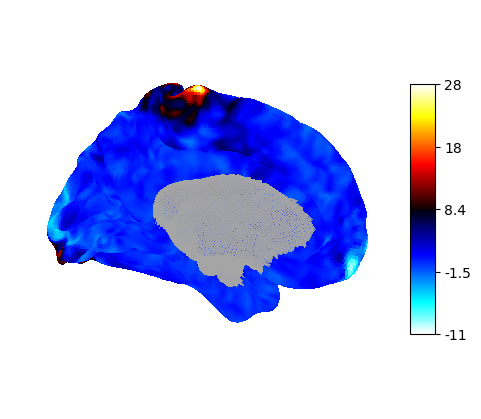

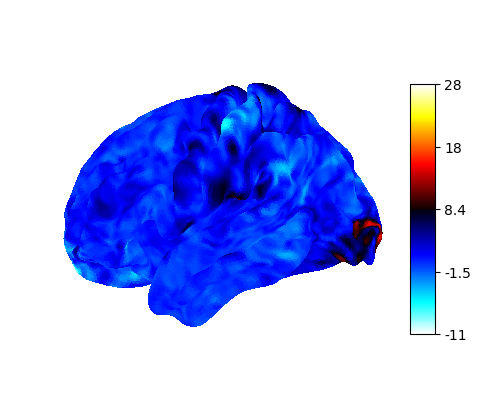

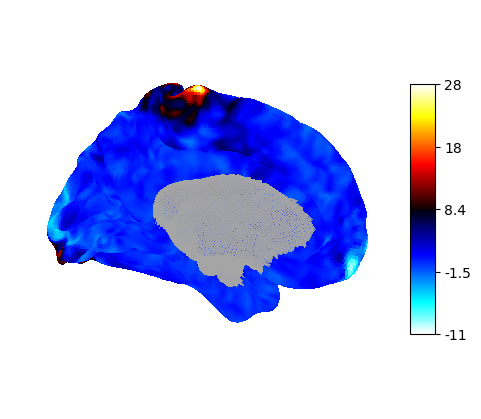

In [ ]:
#pred machine + heatmap
import inspect
from nilearn.plotting import view_surf, plot_surf
from IPython.display import display


print(inspect.signature(view_surf))

idx = np.random.choice(120,size = 1, replace =False)
row= x_te[idx[0]]
Case= row[0:59412].reshape(-1,)

print(f"Case:{idx}")
pred = clf.predict(row.reshape(1,-1))

print(f"Subject is moving their: {CONDS[pred[0]]}")
print(f"Correct? {(pred == y_te[idx])}")

nR = R.agg_data('pointset').shape[0]
mapL = np.full(nL, np.nan)
mapR = np.full(nR, np.nan)
mapL[vL] = Case[0:29696]
mapR[vR] = Case[29696:59412]

plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='lateral')
plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='medial')




In [154]:

row.reshape(1,-1).shape
Case.shape
print("filled verts:", np.count_nonzero(~np.isnan(mapL)), "of", len(mapL))
print("hot verts |v|>3:", int(np.sum(np.abs(np.nan_to_num(mapL)) > 3)))

filled verts: 29696 of 32492
hot verts |v|>3: 11393


left: -42.969207763671875 46.624053955078125
right: -41.54754638671875 50.143829345703125
(surf_mesh=None, surf_map=None, bg_map=None, hemi='left', view=None, engine='matplotlib', cmap=None, symmetric_cmap=None, colorbar=True, avg_method=None, threshold=None, alpha=None, bg_on_data=False, darkness=0.7, vmin=None, vmax=None, cbar_vmin=None, cbar_vmax=None, cbar_tick_format='auto', title=None, title_font_size=None, output_file=None, axes=None, figure=None)


/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/1887774325.py:9: UserWarning: 'symmetric_cmap' is not implemented for the matplotlib engine.
Got 'symmetric_cmap = True'.
Use 'symmetric_cmap = None' to silence this warning.
  plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='lateral')
/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/1887774325.py:9: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='lateral')
/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_3595/1887774325.py:10: UserWarning: 'symmetric_cmap' is not implemented for the matplotlib engine.
Got 'symmetric_cmap = True'.
Use 'symmetric_cmap = None' to silence this warning.
  plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, vi

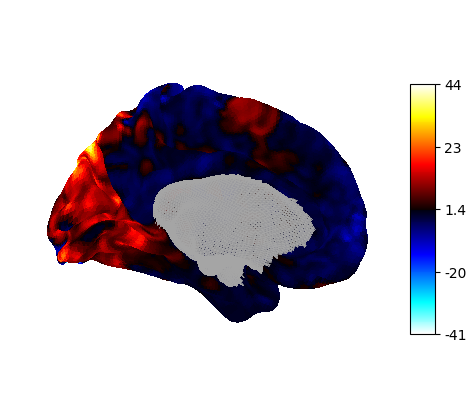

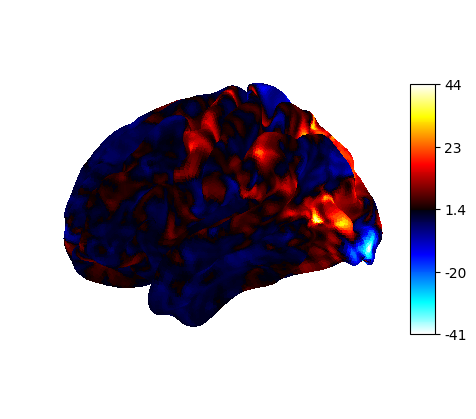

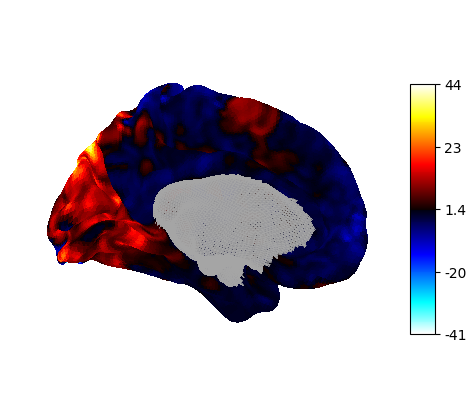

In [ ]:
print("left:", np.nanmin(mapL), np.nanmax(mapL))
print("right:", np.nanmin(mapR), np.nanmax(mapR))


print(inspect.signature(plot_surf))
plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='lateral')
plot_surf(str(surfs['midthickness'].L), surf_map=mapL, cmap='cold_hot', symmetric_cmap=True, view='medial')

In [21]:
# pred machine + interactive 3D glow (one block, run once)
from nilearn.plotting import view_surf
import nibabel as nib
from neuromaps.datasets import fetch_fslr
surfs = fetch_fslr()
L = nib.load(surfs['midthickness'].L)
R = nib.load(surfs['midthickness'].R)

img = nib.load("data/raw/ds004044/derivatives/ciftify/sub-02/results/ses-1_task-motor_hp200_s4_level2.feat/sub-02_ses-1_task-motor_level2_cope_Toe_hp200_s4.dscalar.nii")

ax = img.header.get_axis(1)
for name, slc, bm in ax.iter_structures():
    if name == 'CIFTI_STRUCTURE_CORTEX_LEFT':
        vL = np.asarray(bm.vertex)
    if name == 'CIFTI_STRUCTURE_CORTEX_RIGHT':
        vR = np.asarray(bm.vertex)
nL = L.agg_data('pointset').shape[0]
nR = R.agg_data('pointset').shape[0]

idx = np.random.choice(120, size=1, replace=False)
row = x_te[idx[0]]
Case = row[0:59412]
pred = clf.predict(row.reshape(1, -1))
print(f"Case: {idx}, predicted: {CONDS[pred[0]]}, correct: {CONDS[y_te[idx][0]]}, verdict? {(pred == y_te[idx])[0]}")

mapL0 = np.zeros(nL); mapR0 = np.zeros(nR)
mapL0[vL] = Case[0:29696]; mapR0[vR] = Case[29696:59412]
view = view_surf(str(surfs['midthickness'].L), surf_map=mapL0, cmap='cold_hot', symmetric_cmap=True, threshold=3.0)
view

Case: [77], predicted: RightLeg, correct: RightLeg, verdict? True


/var/folders/nx/30hzfndn1qv9997_rx8zt7680000gn/T/ipykernel_5534/3469248413.py:28: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  view = view_surf(str(surfs['midthickness'].L), surf_map=mapL0, cmap='cold_hot', symmetric_cmap=True, threshold=3.0)


**Final Review:**

GCN test accuracy: 0.125
LR test accuracy: 0:85

Why did the GCN *Fail?*

The controlled experiments convicted the architecture, not the plumbing (shapes, splits, and training mechanics all verified). Deepest reason first:

*Its core prior fights somatotopy. A GCN assumes neighbors behave alike — so it smooths every vertex with its surroundings. But the motor map has sharp borders: hand cortex sits millimeters from face cortex, encoding a different movement. Smoothing across that border blends two classes' signals into neither. The LR wins precisely because it never smooths — each vertex keeps an independent vote, respecting boundaries. Our prior was mismatched to the anatomy: beautiful assumption, wrong map.

*Dilution at readout. Even unsmoothed, the signal lives in small patches; averaging 65k nodes (mean) dissolves them, and keeping one max per channel (max-pool) keeps spikes without context. Neither readout preserves where things are — which is the whole code.

*Scale + schedule as accomplices, not killers. Raw features opened above chance-loss (2.98); standardization fixed conditioning but not the ending, preuve the disease is structural (points 1–2), not optimization. Ten CPU epochs each may also undertrain, but flatlining losses say more time wouldn't resurrect it.

**One line: we built a blur machine for a task decided at sharp borders.**


After this, Im never doubting Linear Regression again😭